In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np


In [2]:
from arlbench_data_analysis import arlbench_data as data
from arlbench_data_analysis.dataset import DataSet

from arlbench_data_analysis.plot import (
    palette, 
    algo_colors, 
    algo_list as algos
)
from arlbench_data_analysis.plot.plot_util import plot_performance_profile_curves, plot_tunability_curves, plot_metrics

from arlbench_data_analysis.metrics.const import metric_arrows
from arlbench_data_analysis.metrics.metrics import TunedScorePerEnv, SpecificityGap, GeneralizationGap

In [3]:
Data = DataSet(data)

# 1. Calculate Ranks

In [4]:
rank_dfs = Data.get_rank_data(perf_column="performance")

# 2. THC values

In [5]:
thc_values = {}
for algo in algos:
    df = rank_dfs[algo]
    df.insert(0, "ptp", df.max(axis=1) - df.min(axis=1))

    # normed ptp is obtained by dividing through the number of rows - 1
    # insert this new column right after ptp
    df.insert(1, "normed_ptp", df["ptp"] / (len(df) - 1) if len(df) > 1 else 0)

    thc_values[algo] = {
        "mean_normed_ptp": df["normed_ptp"].mean(),
        "std_dev_normed_ptp": df["normed_ptp"].std()
    }

In [12]:
# rank_dfs["ppo"].head()

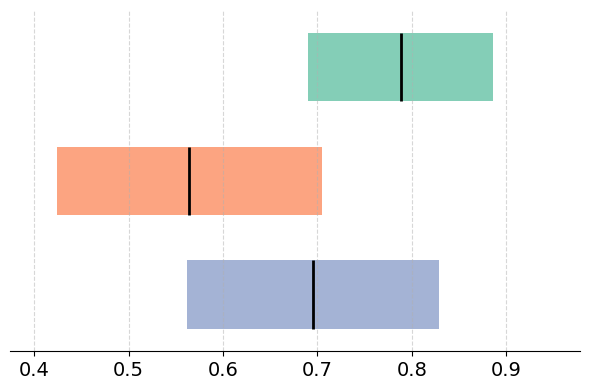

In [6]:
# Recreate the plot for thc_values, remove black outline, sort PPO, DQN, SAC

algo_rows = []
for algo in ["ppo", "dqn", "sac"]:  # enforce order
    if algo in thc_values:
        mean_thc = thc_values[algo]["mean_normed_ptp"]
        std_thc = thc_values[algo]["std_dev_normed_ptp"]
        algo_rows.append({"algorithm": algo.upper(), "thc": mean_thc, "thc_std": std_thc})

algo_df = pd.DataFrame(algo_rows)

# sort algo_df in order ["ppo", "dqn", "sac"]
algo_df = algo_df.set_index("algorithm")
algo_df = algo_df.reindex(["SAC", "DQN", "PPO"])
algo_df = algo_df.reset_index()

fig, ax = plt.subplots(figsize=(6, 4))
palette = sns.color_palette("Set2")
col_map = {"PPO": palette[0], "DQN": palette[1], "SAC": palette[2]}

y = np.arange(len(algo_df))
height = 0.6
for i, row in enumerate(algo_df.itertuples(index=False)):
    left = row.thc - row.thc_std
    width = row.thc_std * 2
    rect = plt.Rectangle((left, i - height/2), width, height,
                         facecolor=col_map[row.algorithm], edgecolor=None, linewidth=0, alpha=0.8)
    ax.add_patch(rect)
    ax.vlines(row.thc, i - height/2, i + height/2, color="black", linewidth=2)

ax.set_yticks(y)
ax.set_yticklabels([])
ax.set_xlabel("")
ax.set_xlim(algo_df["thc"].min() - algo_df["thc_std"].max() -0.05, algo_df["thc"].max() + algo_df["thc_std"].max() + 0.05)
ax.set_ylim(-0.5, len(algo_df) - 0.5)
ax.tick_params(axis="x", labelsize=14) 

# style
ax.grid(axis="x", linestyle="--", alpha=0.5, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

ax.set_title("")
plt.tight_layout()
# plt.rcParams['xtick.labelsize'] = 14
plt.savefig("_figures/adjusted_THC.pdf", bbox_inches='tight')

# 3. Kendall W based on the same ranks 

In [18]:
alg = data["algorithm"].unique()[0]

kendall_w_values = {}

# drop ptp and normed_ptp columns from rank_dfs[alg]
for algo in algos:
    rank_dfs[algo] = rank_dfs[algo].drop(columns=["ptp", "normed_ptp"], errors="ignore")

    # create column R_j which is the mean over rows of the rank_dfs[algo]
    rank_dfs[algo]["R_j"] = rank_dfs[algo].sum(axis=1)
    R_j = rank_dfs[algo]["R_j"].values
    R_bar = R_j.mean()

    S = ((R_j - R_bar) ** 2).sum()

    J = len(R_j)
    M = len(rank_dfs[algo].columns) - 1  # exclude R_j column
    # print(M, J)

    W = 12 * S / (M**2 * J * (J**2 - 1))

    kendall_w_values[algo] = W

print("Kendall's W values:")
for algo, W in kendall_w_values.items():
    print(f"{algo.upper()}: {W:.4f}")   

Kendall's W values:
PPO: 0.0584
DQN: 0.0885
SAC: 0.1181


# 4. Spearman Correlation